# Alarm bouts — clean computational pipeline

Reorganized version of `alarm_bouts.ipynb`. The goal of this notebook is to
**separate computation from plotting**:

- One-time DataFrames that every plot reuses (no recomputation).
- Helper functions that produce per-analysis slices.

After running this top half once, every plotting cell becomes a few lines that
call into the helpers — the per-cell `sub = alarm[...]; mat = sub.pivot(...);
pair = ...` boilerplate is gone.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PARQUET_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")
FIGURES_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/alarm")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]
ICI_BOUT_THRESHOLD_S = 2.0   # silent gap up to this counts as same bout
LIGHT_DEFAULT  = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")


## Load alarm calls with bout annotations

This cell does all the bout-detection plumbing once. After it runs, every row
in `alarm` carries:

- `bout_id` — unique per consecutive run within a `(date_folder, exp, assigned_location)` group, gap ≤ `ICI_BOUT_THRESHOLD_S`.
- `bout_size` — total calls in that bout (broadcast to every row).
- `position` — chronological position within the bout (1 = first call).

In [2]:
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"] == "alarm"]
    parts.append(df_d)
alarm = pd.concat(parts, ignore_index=True)

alarm = alarm.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

prev_stop = alarm.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
gaps = alarm["start_time_real"] - prev_stop
is_new_bout = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_BOUT_THRESHOLD_S))

alarm["bout_id"]   = is_new_bout.cumsum()
alarm["bout_size"] = alarm.groupby("bout_id")["bout_id"].transform("size")
alarm["position"]  = alarm.groupby("bout_id").cumcount() + 1

print(f"{len(alarm):,} alarm calls in {alarm['bout_id'].nunique():,} bouts")
alarm.head(10)


23,560 alarm calls in 8,164 bouts


,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,...,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment,bout_id,bout_size,position
0,235,17,alarm,129.081984,129.124096,0.042112,arena_1,10,0.0,0.889651,...,0.000000,6249.081984,6249.124096,2025-03-21 21:18:59.081984000,2025-03-21 21:18:59.124096,2025_03,1,1,1,1
1,235,25,alarm,72.771072,72.793344,0.022272,arena_1,10,0.0,0.880208,...,0.009429,9072.771072,9072.793344,2025-03-21 22:06:02.771072000,2025-03-21 22:06:02.793344,2025_03,1,2,1,1
2,235,28,alarm,146.619520,146.703608,0.084088,arena_1,10,0.0,0.830831,...,0.011916,10226.619520,10226.703608,2025-03-21 22:25:16.619520000,2025-03-21 22:25:16.703608,2025_03,1,3,1,1
3,235,38,alarm,171.055616,171.290488,0.234872,arena_1,10,0.0,0.848390,...,0.003287,13851.055616,13851.290488,2025-03-21 23:25:41.055616000,2025-03-21 23:25:41.290488,2025_03,1,4,13,1
4,235,38,alarm,172.338048,172.536064,0.198016,arena_1,10,0.0,0.861168,...,0.002278,13852.338048,13852.536064,2025-03-21 23:25:42.338048000,2025-03-21 23:25:42.536064,2025_03,1,4,13,2
5,235,38,alarm,173.141888,173.329784,0.187896,arena_1,10,0.0,0.866764,...,0.002422,13853.141888,13853.329784,2025-03-21 23:25:43.141888000,2025-03-21 23:25:43.329784,2025_03,1,4,13,3
6,235,38,alarm,173.906304,174.065024,0.158720,arena_1,10,0.0,0.818164,...,0.009293,13853.906304,13854.065024,2025-03-21 23:25:43.906304000,2025-03-21 23:25:44.065024,2025_03,1,4,13,4
7,235,38,alarm,174.540032,174.685688,0.145656,arena_1,10,0.0,0.811110,...,0.006027,13854.540032,13854.685688,2025-03-21 23:25:44.540032000,2025-03-21 23:25:44.685688,2025_03,1,4,13,5
8,235,38,alarm,176.517376,176.627576,0.110200,arena_1,10,0.0,0.808564,...,0.007077,13856.517376,13856.627576,2025-03-21 23:25:46.517375999,2025-03-21 23:25:46.627576,2025_03,1,4,13,6
9,235,38,alarm,178.367360,178.489600,0.122240,arena_1,10,0.0,0.822840,...,0.009989,13858.367360,13858.489600,2025-03-21 23:25:48.367360000,2025-03-21 23:25:48.489600,2025_03,1,4,13,7


## `bouts_meta` — one row per bout

Most analyses ask questions *per bout*: "where did it happen?", "how long was it?",
"what time did it start?". This DataFrame answers all of those in one place,
indexed by `bout_id`. Every later cell that needs bout-level metadata pulls
from here instead of regrouping `alarm`.

The trick: every column we want is constant within a bout, so we can take the
position-1 row as a representative.

In [3]:
bouts_meta = (
    alarm[alarm["position"] == 1]
    .set_index("bout_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "bout_size",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .copy()
)

# Per-row light window: look up by date_folder.
light_starts = bouts_meta["date_folder"].map(
    lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0]
)
light_ends = bouts_meta["date_folder"].map(
    lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1]
)

hours = bouts_meta["start_time_real"].dt.hour

# Standard window (light_start < light_end) vs wrap-around (light_start > light_end).
# np.where(condition, value_if_true, value_if_false) is vectorized — applied
# row-by-row to all three Series simultaneously.
in_light = np.where(
    light_starts < light_ends,
    (hours >= light_starts) & (hours < light_ends),
    (hours >= light_starts) | (hours <  light_ends),
)

bouts_meta["light_dark"] = np.where(in_light, "light", "dark")

# Add bout duration to bouts_meta.
bout_span = alarm.groupby("bout_id")["start_time_real"].agg(["min", "max"])
bouts_meta["duration_s"] = (bout_span["max"] - bout_span["min"]).dt.total_seconds()

print(bouts_meta["light_dark"].value_counts())
bouts_meta[["date_folder", "start_time_real", "light_dark"]].head()


print(f"{len(bouts_meta):,} bouts")
bouts_meta.head()


light_dark
light    5410
dark     2754
Name: count, dtype: int64
8,164 bouts


,date_folder,exp,file_num,assigned_location,bout_size,start_time_real,start_time_file_sec,start_time_experiment_sec,day_in_experiment,light_dark,duration_s
bout_id,,,,,,,,,,,
1,2025_03,235,17,arena_1,1,2025-03-21 21:18:59.081984,129.081984,6249.081984,1,dark,0.00000
2,2025_03,235,25,arena_1,1,2025-03-21 22:06:02.771072,72.771072,9072.771072,1,dark,0.00000
3,2025_03,235,28,arena_1,1,2025-03-21 22:25:16.619520,146.619520,10226.619520,1,dark,0.00000
4,2025_03,235,38,arena_1,13,2025-03-21 23:25:41.055616,171.055616,13851.055616,1,dark,11.99232
5,2025_03,235,59,arena_1,1,2025-03-22 01:32:13.680896,203.680896,21443.680896,2,dark,0.00000


In [4]:
# === Derived per-bout regularity statistics ===
# Adds:
#   - alarm["ici_s"]          : within-bout inter-call interval, in seconds
#   - bouts_meta["mean_ici"]  : per-bout mean ICI
#   - bouts_meta["std_ici"]   : per-bout std of ICIs
#   - bouts_meta["n_ici"]     : how many ICIs each bout has (= bout_size - 1)
#   - bouts_meta["cv_ici"]    : per-bout CV of ICIs (std/mean)

# 1) Within-bout ICI per call. The first call of each bout gets NaN.
alarm["ici_s"] = (
    alarm.groupby("bout_id")["start_time_real"]
    .diff()
    .dt.total_seconds()
)

# 2) Per-bout aggregates: mean, std, count of ICIs.
ici_stats = (
    alarm.dropna(subset=["ici_s"])
    .groupby("bout_id")["ici_s"]
    .agg(mean_ici="mean", std_ici="std", n_ici="size")
)

# 3) Push onto bouts_meta. reindex aligns by bout_id; bouts with <2 ICIs
# (size 1 or 2) get NaN, which downstream filters then exclude.
bouts_meta["mean_ici"] = ici_stats["mean_ici"]
bouts_meta["std_ici"]  = ici_stats["std_ici"]
bouts_meta["n_ici"]    = ici_stats["n_ici"]
bouts_meta["cv_ici"]   = bouts_meta["std_ici"] / bouts_meta["mean_ici"]

# Quick sanity print.
print(f"alarm: ici_s computed for {alarm['ici_s'].notna().sum():,} of {len(alarm):,} calls")
print(f"bouts_meta: cv_ici computed for {bouts_meta['cv_ici'].notna().sum():,} of {len(bouts_meta):,} bouts")
print(bouts_meta[["bout_size", "mean_ici", "std_ici", "cv_ici"]].describe())


alarm: ici_s computed for 15,396 of 23,560 calls
bouts_meta: cv_ici computed for 1,624 of 8,164 bouts
         bout_size     mean_ici      std_ici       cv_ici
count  8164.000000  2913.000000  1624.000000  1624.000000
mean      2.885840     0.802405     0.395254     0.511301
std       7.539415     0.468318     0.234637     0.304680
min       1.000000     0.017024     0.000091     0.000116
25%       1.000000     0.505448     0.240920     0.312316
50%       1.000000     0.791142     0.382649     0.474231
75%       2.000000     1.090112     0.529412     0.667780
max     293.000000     2.156288     1.387061     1.778346


## `duration_by_position` — wide-format duration matrix

One row per bout, one column per position, values are call durations (NaN where
the bout doesn't have that position). Built **once on the full alarm dataset**
— per-analysis filtering happens by selecting rows from this matrix, not by
re-pivoting.

This is the most expensive computation in the notebook; doing it once instead
of inside every plotting cell saves real time.

In [60]:
duration_by_position = alarm.pivot(
    index="bout_id", columns="position", values="duration_sec"
)
print(f"{duration_by_position.shape[0]:,} bouts × {duration_by_position.shape[1]} max positions")
duration_by_position.head()


8,164 bouts × 293 max positions


position,1,2,3,4,5,6,7,8,9,10,...,284,285,286,287,288,289,290,291,292,293
bout_id,,,,,,,,,,,,,,,,,,,,,
1,0.042112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.022272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.084088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.234872,0.198016,0.187896,0.15872,0.145656,0.1102,0.12224,0.148736,0.100864,0.099712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.092920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## `get_pair(...)` — produce the first/last/diff slice for any analysis

The recurring pattern in every plotting cell was:
1. Filter `alarm` by date/location/min_size.
2. Pivot to (bout × position).
3. Pull columns 1 and N, drop NaN, compute diff.

This function does all of that, using the precomputed `bouts_meta` and
`duration_by_position`, so no re-filtering or re-pivoting happens. Returns a
DataFrame with `first`, `last`, `diff`, and `bout_size`, indexed by bout_id.

In [16]:
def get_pair(last_pos, *, location=None, date_folder=None, min_size=None):
    """Return a per-bout DataFrame [first, last, diff, ratio, bout_size]
    for the requested slice."""
    keep = bouts_meta
    if location is not None:
        keep = keep[keep["assigned_location"] == location]
    if date_folder is not None:
        keep = keep[keep["date_folder"] == date_folder]
    if min_size is None:
        min_size = last_pos
    keep = keep[keep["bout_size"] >= min_size]

    if keep.empty:
        return None

    sub_mat = duration_by_position.loc[keep.index]
    pair = pd.concat({"first": sub_mat[1], "last": sub_mat[last_pos]}, axis=1).dropna()
    pair = pair[pair["first"] > 0]                # avoid div-by-zero
    pair["diff"]      = pair["first"] - pair["last"]
    pair["ratio"]     = pair["last"] / pair["first"]
    pair["bout_size"] = bouts_meta.loc[pair.index, "bout_size"]
    return pair



In [19]:
LAST_POS = 7
TOP_N = 10

pair = get_pair(LAST_POS, location="underground")
#pair.head(10)
sorted_bouts = (pair.join(bouts_meta[["date_folder", "exp", "file_num", "start_time_file_sec","start_time_real","light_dark"]]).sort_values("ratio", ascending=True))

print(f"Top {TOP_N} bouts by (first − call {LAST_POS}) duration drop:")
print(sorted_bouts.head(TOP_N).to_string())


Top 10 bouts by (first − call 7) duration drop:
            first      last      diff     ratio  bout_size date_folder  exp  file_num  start_time_file_sec            start_time_real light_dark
bout_id                                                                                                                                         
5403     0.229120  0.018944  0.210176  0.082682        128     2025_10  340       192           132.811776 2025-10-15 13:00:03.811776      light
6126     0.214912  0.023544  0.191368  0.109552         12     2025_10  343       133            42.870144 2025-10-18 08:11:06.870144      light
1055     0.164600  0.019584  0.145016  0.118979         13     2025_03  237        76           204.609536 2025-03-22 19:55:12.609536      light
6237     0.235640  0.029560  0.206080  0.125446          9     2025_10  343       248           222.168064 2025-10-18 19:44:06.168064      light
7580     0.202232  0.025600  0.176632  0.126587         11     2026_02  506       

## Plotting



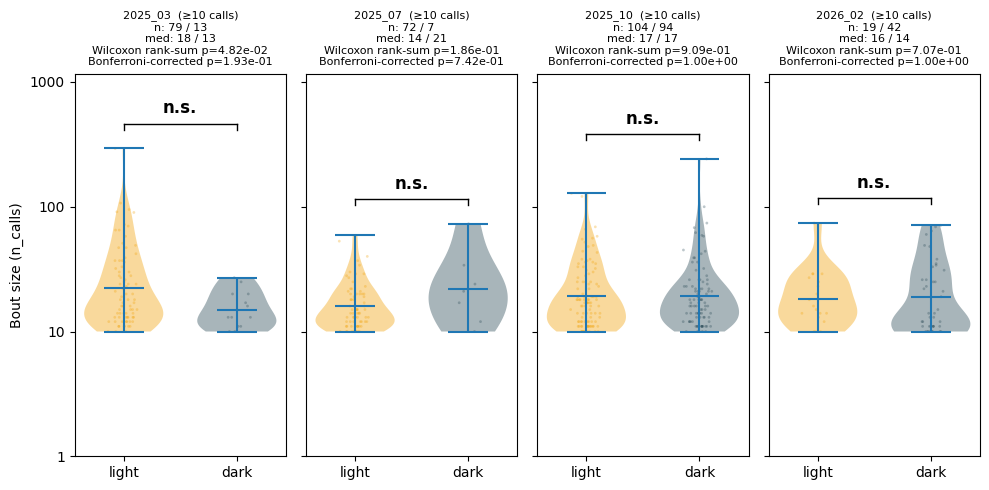

In [5]:
from scipy.stats import mannwhitneyu

MIN_BOUT_SIZE = 10
LIGHT_DARK_COLORS = {"light": "#F1A208", "dark": "#264653"}
N_TESTS = len(DATES_TO_PLOT)


def stars(p):
    if np.isnan(p):  return "—"
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "n.s."


fig, axes = plt.subplots(
    1, len(DATES_TO_PLOT),
    figsize=(2.5 * len(DATES_TO_PLOT), 5),
    sharey=True,
)

global_top = 0.0   # for sharey: track the tallest bracket so we can extend ylim once at the end

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date_tag)
        & (bouts_meta["bout_size"] >= MIN_BOUT_SIZE)
    ]

    light_vals = sub[sub["light_dark"] == "light"]["bout_size"].values
    dark_vals  = sub[sub["light_dark"] == "dark"]["bout_size"].values

    if len(light_vals) > 0 and len(dark_vals) > 0:
        _, p_raw = mannwhitneyu(light_vals, dark_vals)
        p_bonf = min(p_raw * N_TESTS, 1.0)
    else:
        p_raw = p_bonf = float("nan")

    log_data = {
        "light": np.log10(light_vals) if len(light_vals) else np.array([]),
        "dark":  np.log10(dark_vals)  if len(dark_vals)  else np.array([]),
    }

    if all(len(v) > 0 for v in log_data.values()):
        parts = ax.violinplot(
            list(log_data.values()),
            positions=[0, 1], showmeans=True, widths=0.7,
        )
        for pc, color in zip(parts["bodies"], LIGHT_DARK_COLORS.values()):
            pc.set_facecolor(color)
            pc.set_alpha(0.4)

    rng = np.random.default_rng(0)
    for x, (cls, vals) in zip([0, 1], log_data.items()):
        jitter = rng.normal(0, 0.06, len(vals))
        ax.scatter(x + jitter, vals,
                   s=4, alpha=0.3, color=LIGHT_DARK_COLORS[cls],
                   edgecolor="none")

    # Significance bracket above the violins.
    top = max(
        log_data["light"].max() if len(log_data["light"]) else 0,
        log_data["dark"].max()  if len(log_data["dark"])  else 0,
    )
    bracket_y = top + 0.20
    tick_h    = 0.05

    ax.plot([0, 1], [bracket_y, bracket_y], color="black", linewidth=1)
    ax.plot([0, 0], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.plot([1, 1], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.text(0.5, bracket_y + 0.05, stars(p_bonf),
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    global_top = max(global_top, bracket_y + 0.4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["light", "dark"])
    ax.set_title(
        f"{date_tag}  (≥{MIN_BOUT_SIZE} calls)\n"
        f"n: {len(light_vals)} / {len(dark_vals)}\n"
        f"med: {np.median(light_vals):.0f} / {np.median(dark_vals):.0f}\n"
        f"Wilcoxon rank-sum p={p_raw:.2e}\n"
        f"Bonferroni-corrected p={p_bonf:.2e}",
        fontsize=8,
    )

# Y-axis: log10 → original counts; extend top to make room for brackets.
yticks = [0, 1, 2, 3]
axes[0].set_yticks(yticks)
axes[0].set_yticklabels([str(10**y) for y in yticks])
axes[0].set_ylabel("Bout size (n_calls)")
axes[0].set_ylim(top=global_top)   # propagates to all via sharey

fig.tight_layout()
save_fig(fig, f"bout_size_violin_light_vs_dark_min{MIN_BOUT_SIZE}")
plt.show()


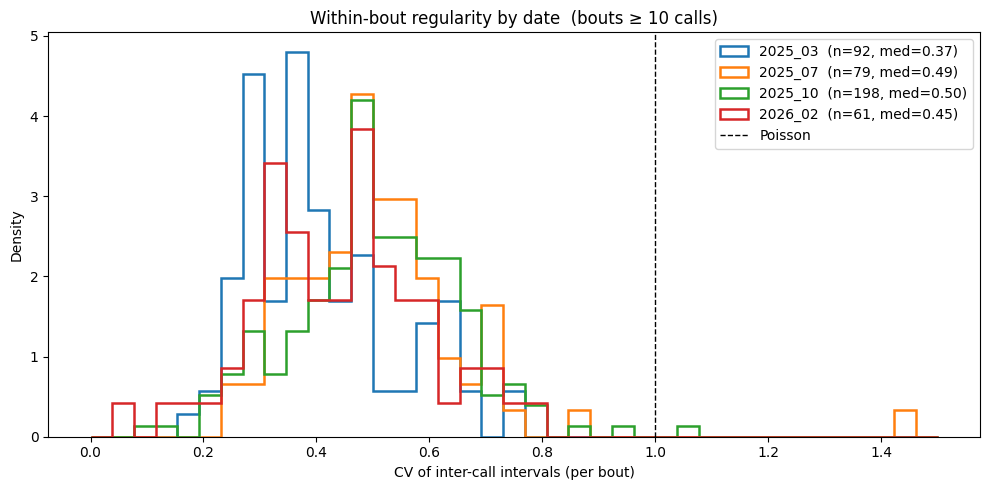

In [6]:
MIN_CALLS_FOR_CV = 10

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1.5, 40)

date_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(DATES_TO_PLOT)]

for date_tag, color in zip(DATES_TO_PLOT, date_colors):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date_tag)
        & (bouts_meta["bout_size"] >= MIN_CALLS_FOR_CV)
    ]["cv_ici"].dropna()
    if sub.empty:
        continue
    ax.hist(sub, bins=bins, histtype="step", linewidth=1.8, color=color,
            label=f"{date_tag}  (n={len(sub):,}, med={sub.median():.2f})",
            density=True)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.0, label="Poisson")
ax.set_xlabel("CV of inter-call intervals (per bout)")
ax.set_ylabel("Density")
ax.set_title(f"Within-bout regularity by date  (bouts ≥ {MIN_CALLS_FOR_CV} calls)")
ax.legend()
fig.tight_layout()
save_fig(fig, f"bout_within_cv_by_date_overlay_min{MIN_CALLS_FOR_CV}")
plt.show()


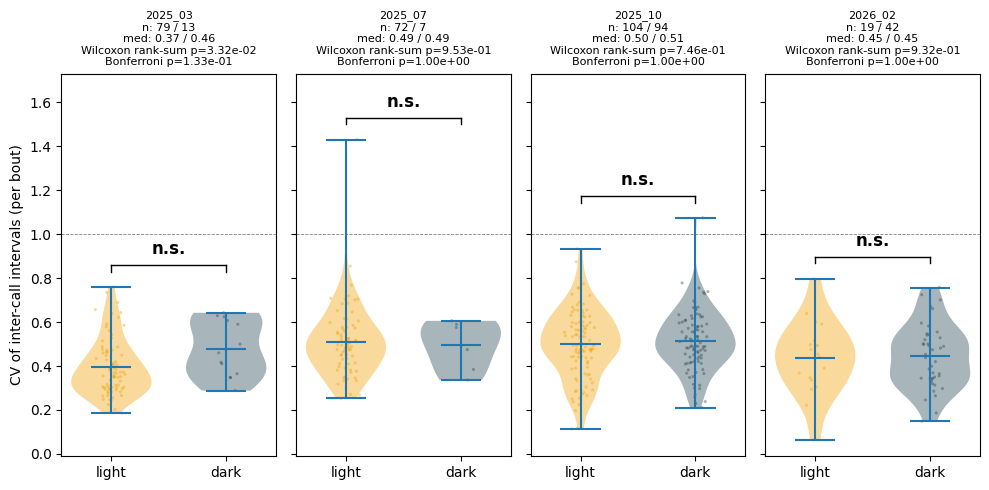

In [7]:
from scipy.stats import mannwhitneyu

MIN_CALLS_FOR_CV = 10
LIGHT_DARK_COLORS = {"light": "#F1A208", "dark": "#264653"}
N_TESTS = len(DATES_TO_PLOT)


def stars(p):
    if np.isnan(p):  return "—"
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "n.s."


fig, axes = plt.subplots(
    1, len(DATES_TO_PLOT),
    figsize=(2.5 * len(DATES_TO_PLOT), 5),
    sharey=True,
)
global_top = 0.0

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date_tag)
        & (bouts_meta["bout_size"] >= MIN_CALLS_FOR_CV)
        & bouts_meta["cv_ici"].notna()
    ]

    light_vals = sub[sub["light_dark"] == "light"]["cv_ici"].values
    dark_vals  = sub[sub["light_dark"] == "dark"]["cv_ici"].values

    if len(light_vals) >= 3 and len(dark_vals) >= 3:
        _, p_raw = mannwhitneyu(light_vals, dark_vals)
        p_bonf = min(p_raw * N_TESTS, 1.0)
    else:
        p_raw = p_bonf = float("nan")

    data = {"light": light_vals, "dark": dark_vals}

    if all(len(v) > 0 for v in data.values()):
        parts = ax.violinplot(
            list(data.values()),
            positions=[0, 1], showmeans=True, widths=0.7,
        )
        for pc, color in zip(parts["bodies"], LIGHT_DARK_COLORS.values()):
            pc.set_facecolor(color)
            pc.set_alpha(0.4)

    rng = np.random.default_rng(0)
    for x, (cls, vals) in zip([0, 1], data.items()):
        if len(vals) == 0:
            continue
        jitter = rng.normal(0, 0.06, len(vals))
        ax.scatter(x + jitter, vals,
                   s=5, alpha=0.4, color=LIGHT_DARK_COLORS[cls],
                   edgecolor="none")

    # Significance bracket.
    top = max(
        light_vals.max() if len(light_vals) else 0,
        dark_vals.max()  if len(dark_vals)  else 0,
    )
    bracket_y = top + 0.10
    tick_h    = 0.03
    ax.plot([0, 1], [bracket_y, bracket_y], color="black", linewidth=1)
    ax.plot([0, 0], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.plot([1, 1], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.text(0.5, bracket_y + 0.03, stars(p_bonf),
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    global_top = max(global_top, bracket_y + 0.2)

    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.6, zorder=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["light", "dark"])
    ax.set_title(
        f"{date_tag}\n"
        f"n: {len(light_vals)} / {len(dark_vals)}\n"
        f"med: {np.median(light_vals) if len(light_vals) else float('nan'):.2f} / "
        f"{np.median(dark_vals) if len(dark_vals) else float('nan'):.2f}\n"
        f"Wilcoxon rank-sum p={p_raw:.2e}\n"
        f"Bonferroni p={p_bonf:.2e}",
        fontsize=8,
    )

axes[0].set_ylabel("CV of inter-call intervals (per bout)")
axes[0].set_ylim(top=global_top)

fig.tight_layout()
save_fig(fig, "bout_cv_violin_light_vs_dark")
plt.show()


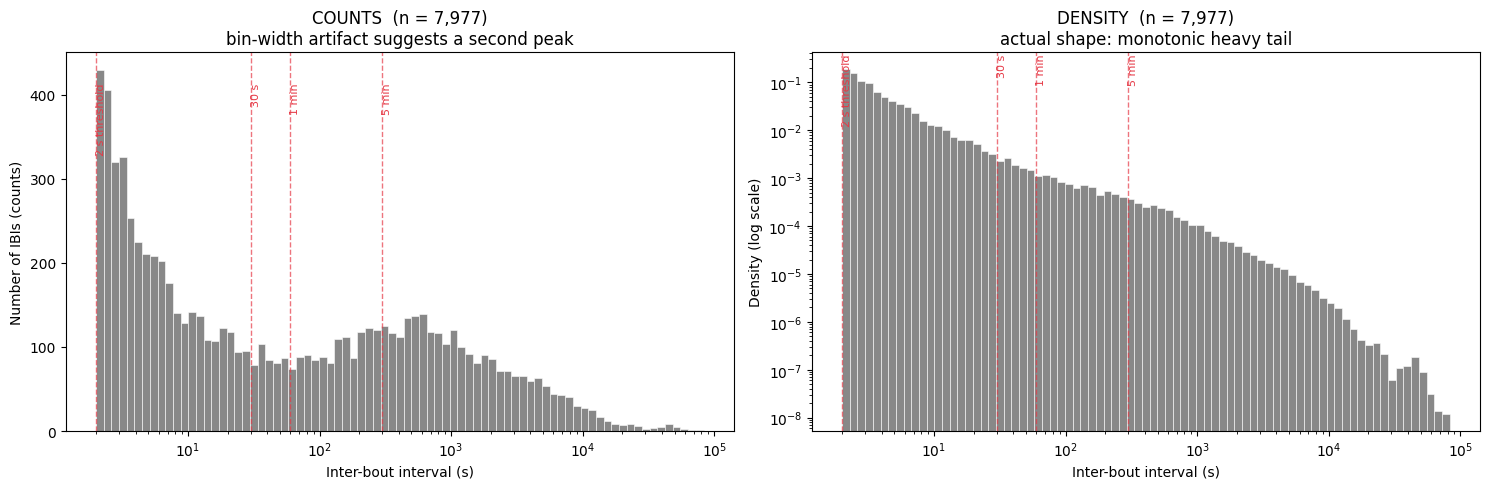

In [14]:
ibi = bouts_meta["ibi_s"].dropna()
bins = np.geomspace(ibi.min(), ibi.max(), 80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Count version — what we plotted originally. Misleading on log bins.
axes[0].hist(ibi, bins=bins, color="#888888", edgecolor="white", linewidth=0.4)
axes[0].set_xscale("log")
axes[0].set_xlabel("Inter-bout interval (s)")
axes[0].set_ylabel("Number of IBIs (counts)")
axes[0].set_title(f"COUNTS  (n = {len(ibi):,})\nbin-width artifact suggests a second peak")

# (b) Density version — divides out the bin width, so the visual is faithful.
axes[1].hist(ibi, bins=bins, color="#888888", edgecolor="white", linewidth=0.4,
             density=True)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Inter-bout interval (s)")
axes[1].set_ylabel("Density (log scale)")
axes[1].set_title(f"DENSITY  (n = {len(ibi):,})\nactual shape: monotonic heavy tail")

# Same threshold markers on both panels.
for ax in axes:
    for t, label in [(2, "2 s threshold"), (30, "30 s"), (60, "1 min"), (300, "5 min")]:
        ax.axvline(t, color="#E63946", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(t, ax.get_ylim()[1] * 0.92, f"  {label}",
                rotation=90, fontsize=8, color="#E63946", va="top")

fig.tight_layout()
save_fig(fig, "ibi_pooled_counts_vs_density")
plt.show()


In [15]:
from sklearn.mixture import GaussianMixture
log_ibi = np.log10(bouts_meta["ibi_s"].dropna()).values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=0).fit(log_ibi)
print("Mixture means (in seconds):", 10**gmm.means_.flatten())
print("Mixture weights:", gmm.weights_)


Mixture means (in seconds): [  4.34368052 281.63984004]
Mixture weights: [0.4050591 0.5949409]


In [4]:
# Per-date IBI distribution. Shared bins + density-normalized so shapes are directly comparable.
ibi_all = bouts_meta["ibi_s"].dropna()
bins = np.geomspace(ibi_all.min(), ibi_all.max(), 60)

CURRENT_THRESHOLD_S = 2     # the bout-detection cutoff actually used

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.3 * len(DATES_TO_PLOT)),
    sharex=True, sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[bouts_meta["date_folder"] == date_tag]["ibi_s"].dropna()
    if sub.empty:
        ax.text(0.5, 0.5, "no IBIs", ha="center", va="center", transform=ax.transAxes)
        continue

    ax.hist(sub, bins=bins, color="#888888", edgecolor="white",
            linewidth=0.4, density=True)
    ax.set_xscale("log")

    # Reference markers — same on every panel for easy comparison.
    for t, label in [
        (CURRENT_THRESHOLD_S, f"{CURRENT_THRESHOLD_S}s (current)"),
        (30, "30 s"),
        (60, "1 min"),
        (300, "5 min"),
    ]:
        ax.axvline(t, color="#E63946", linestyle="--", linewidth=1, alpha=0.7)
        # Label only on the top panel to avoid clutter.
        if ax is axes[0]:
            ax.text(t, ax.get_ylim()[1] * 0.92, f"  {label}",
                    rotation=90, fontsize=8, color="#E63946", va="top")

    ax.set_title(f"{date_tag}   (n={len(sub):,} IBIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")

axes[-1].set_xlabel("Inter-bout interval (s)")
fig.tight_layout()
save_fig(fig, "inter_bout_interval_per_date")
plt.show()


KeyError: 'ibi_s'

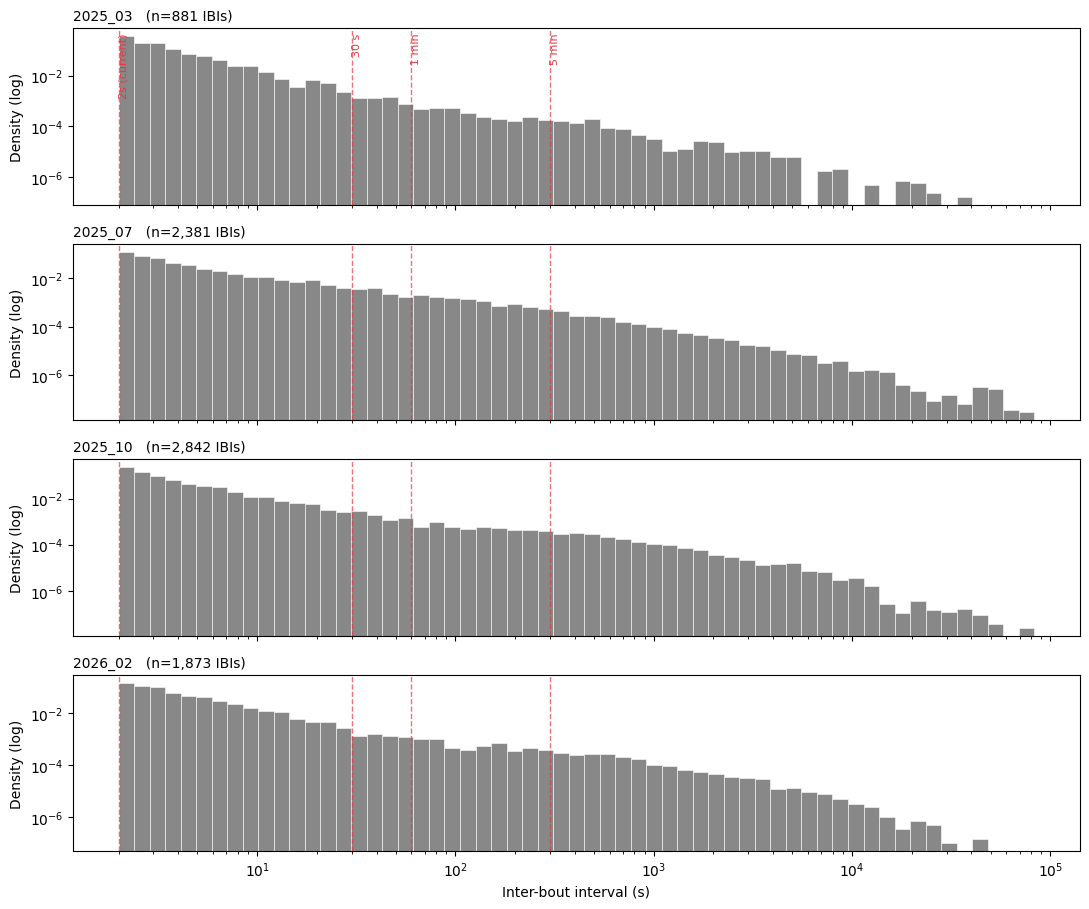

In [18]:
ibi_all = bouts_meta["ibi_s"].dropna()
bins = np.geomspace(ibi_all.min(), ibi_all.max(), 60)

CURRENT_THRESHOLD_S = 2

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.3 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,        # let each panel use its own y-range
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[bouts_meta["date_folder"] == date_tag]["ibi_s"].dropna()
    if sub.empty:
        ax.text(0.5, 0.5, "no IBIs", ha="center", va="center", transform=ax.transAxes)
        continue

    ax.hist(sub, bins=bins, color="#888888", edgecolor="white",
            linewidth=0.4, density=True)
    ax.set_xscale("log")
    ax.set_yscale("log")              # log-y reveals the second peak

    for t, label in [
        (CURRENT_THRESHOLD_S, f"{CURRENT_THRESHOLD_S}s (current)"),
        (30, "30 s"),
        (60, "1 min"),
        (300, "5 min"),
    ]:
        ax.axvline(t, color="#E63946", linestyle="--", linewidth=1, alpha=0.7)
        if ax is axes[0]:
            ax.text(t, ax.get_ylim()[1] * 0.7, f"  {label}",
                    rotation=90, fontsize=8, color="#E63946", va="top")

    ax.set_title(f"{date_tag}   (n={len(sub):,} IBIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density (log)")

axes[-1].set_xlabel("Inter-bout interval (s)")
fig.tight_layout()
save_fig(fig, "inter_bout_interval_per_date_logy")
plt.show()


=== Per-date GMM fit ===
date_folder    n  mode_short_s  mode_long_s  weight_short  weight_long  logstd_short  logstd_long  boundary_s
    2025_03  881          3.91        144.1         0.660        0.340          0.22         0.93        13.0
    2025_07 2381          3.70        164.9         0.207        0.793          0.19         0.88         1.0
    2025_10 2842          4.33        371.1         0.445        0.555          0.27         0.81        16.2
    2026_02 1873          5.30        549.0         0.466        0.534          0.31         0.75        24.8



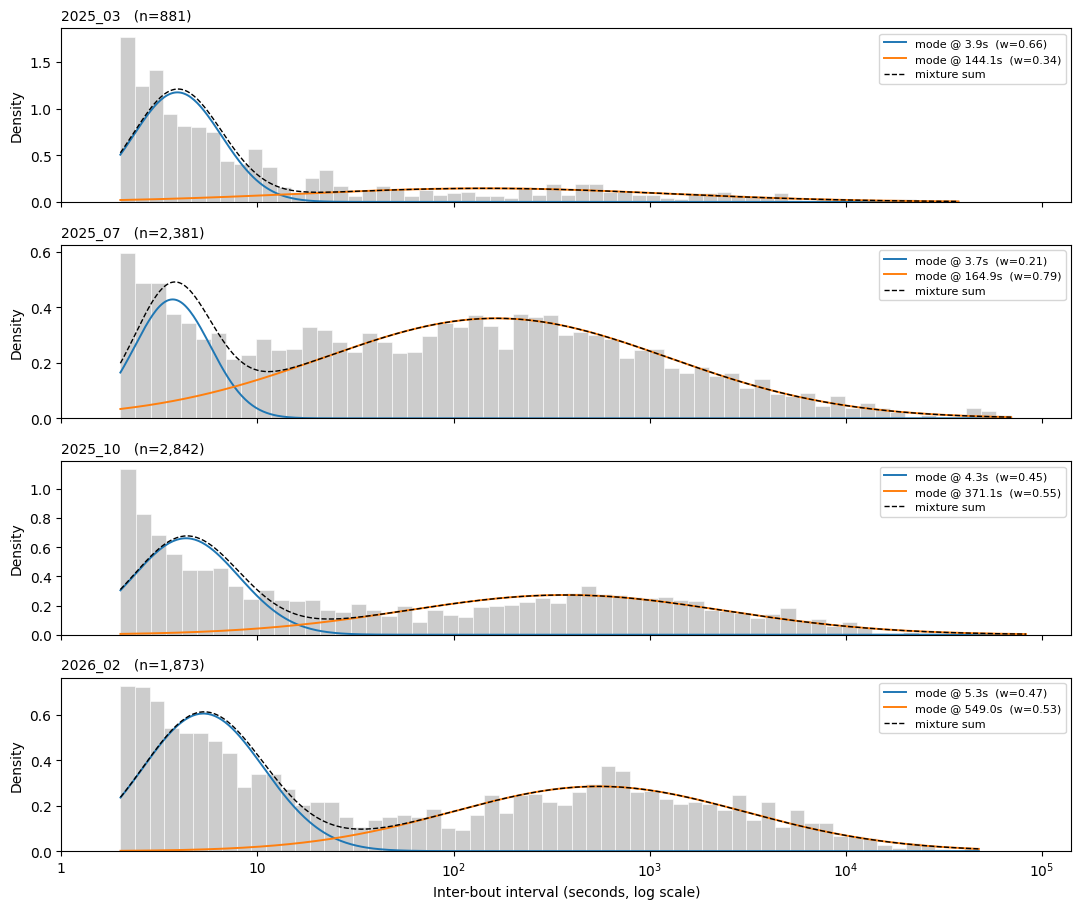

In [16]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Fit per date, collect parameters.
rows = []
fits = {}
for date_tag in DATES_TO_PLOT:
    sub = bouts_meta[bouts_meta["date_folder"] == date_tag]["ibi_s"].dropna()
    if len(sub) < 50:
        rows.append({"date_folder": date_tag, "n": len(sub), "note": "too few"})
        continue

    log_sub = np.log10(sub).values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=0).fit(log_sub)
    fits[date_tag] = (sub, gmm)

    means_log   = gmm.means_.flatten()
    means_s     = 10**means_log
    weights     = gmm.weights_
    stds_log    = np.sqrt(gmm.covariances_).flatten()
    short_idx   = np.argmin(means_s)
    long_idx    = 1 - short_idx

    # GMM decision boundary (where posterior of mode_short crosses 0.5).
    test_log = np.linspace(np.log10(1), np.log10(10_000), 5000).reshape(-1, 1)
    post = gmm.predict_proba(test_log)
    cross = test_log[post[:, short_idx] < 0.5]
    boundary_s = 10**cross[0, 0] if len(cross) > 0 else np.nan

    rows.append({
        "date_folder":   date_tag,
        "n":             len(sub),
        "mode_short_s":  round(means_s[short_idx], 2),
        "mode_long_s":   round(means_s[long_idx], 1),
        "weight_short":  round(weights[short_idx], 3),
        "weight_long":   round(weights[long_idx], 3),
        "logstd_short":  round(stds_log[short_idx], 2),
        "logstd_long":   round(stds_log[long_idx], 2),
        "boundary_s":    round(boundary_s, 1),
    })

per_date = pd.DataFrame(rows)
print("=== Per-date GMM fit ===")
print(per_date.to_string(index=False))
print()

# Overlay each date's histogram with its fitted mixture, in log10 space.
fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.3 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    if date_tag not in fits:
        ax.text(0.5, 0.5, f"{date_tag}: too few IBIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    sub, gmm = fits[date_tag]
    log_sub = np.log10(sub).values

    bins = np.linspace(log_sub.min(), log_sub.max(), 60)
    ax.hist(log_sub, bins=bins, density=True, color="#cccccc",
            edgecolor="white", linewidth=0.4)

    means_log = gmm.means_.flatten()
    weights   = gmm.weights_
    stds_log  = np.sqrt(gmm.covariances_).flatten()

    x_grid = np.linspace(bins.min(), bins.max(), 500)
    pdf_total = np.zeros_like(x_grid)
    for i in range(2):
        comp = weights[i] * norm.pdf(x_grid, means_log[i], stds_log[i])
        pdf_total += comp
        ax.plot(x_grid, comp, linewidth=1.4,
                label=f"mode @ {10**means_log[i]:.1f}s  (w={weights[i]:.2f})")
    ax.plot(x_grid, pdf_total, color="black", linewidth=1.0, linestyle="--",
            label="mixture sum")

    ax.set_title(f"{date_tag}   (n={len(sub):,})", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

# Convert log-x ticks back to seconds.
log_ticks = [0, 1, 2, 3, 4, 5]
axes[-1].set_xticks(log_ticks)
axes[-1].set_xticklabels([f"$10^{t}$" if t > 1 else f"{10**t:.0f}" for t in log_ticks])
axes[-1].set_xlabel("Inter-bout interval (seconds, log scale)")

fig.tight_layout()
save_fig(fig, "gmm_fit_per_date")
plt.show()
